Build simple 2-3 layer CNN
Train baseline model
Evaluate on validation set
Get initial accuracy (~70-80%)
Save model checkpoint

This notebook covers:
- Building a simple baseline CNN (2-3 layers)
- Training the baseline model
- Evaluating performance on validation set
- Saving model and metrics

import libs and load preprocessed data (from notebook 2)

In [1]:
#imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from datetime import datetime
from tensorflow.keras import models, layers

# tensorflow import
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#for metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#random seed for reporoductivity (default 42)
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)


In [2]:
#rerun preprocessing (copy from Notebook 2)
from sklearn.model_selection import train_test_split

#load raw data
train_data = pd.read_csv('../data/sign_mnist_train.csv')
test_data = pd.read_csv('../data/sign_mnist_test.csv')

#separate features and labels
X_train_full = train_data.drop('label', axis=1).values
y_train_full = train_data['label'].values

#preprocess
X_train_full = X_train_full / 255.0  # Normalize
X_train_full = X_train_full.reshape(-1, 28, 28, 1)  # Reshape

# one hot encode
y_train_full_encoded = keras.utils.to_categorical(y_train_full, 25)

# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print(f"   Training set: {X_train.shape[0]:,} images")
print(f"   Validation set: {X_val.shape[0]:,} images")
print(f"   Image shape: {X_train.shape[1:]}")
print(f"   Number of classes: {y_train.shape[1]}")

   Training set: 21,964 images
   Validation set: 5,491 images
   Image shape: (28, 28, 1)
   Number of classes: 25


design baseline cnn 

In [ ]:
#build the model
baseline_model = models.Sequential([
    #input layer - expects 28x28x1 grayscale images
    layers.Input(shape=(28, 28, 1)),
    
    #convolutional layer: Find 32 different patterns in the image
    # (3,3) = look at 3x3 pixel squares
    #relu = activation function (makes model learn non-linear patterns)
    layers.Conv2D(32, (3, 3), activation='relu', name='conv1'),
    
    #max pooling: Reduce size by taking max of each 2x2 square
    #makes it faster and helps prevent overfitting
    layers.MaxPooling2D((2, 2), name='pool1'),
    
    #flatten: Convert 2D image to 1D array
    layers.Flatten(name='flatten'),
    
    #dense layer: add some complexity before final decision
    layers.Dense(64, activation='relu', name='dense1'),
    
    #output layer: 24 outputs (one per letter)
    #softmax = convert to probabilities that sum to 1
    layers.Dense(25, activation='softmax', name='output')
], name='baseline_cnn')

print("\nBaseline model created!")
print("\nModel Architecture Summary:")
baseline_model.summary()

#calculate total params
total_params = baseline_model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")



Baseline model created!

Model Architecture Summary:


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,121 (1.33 MB)

 Trainable params: 348,121 (1.33 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 348,121


### results 

Baseline model created!

Model Architecture Summary:
Model: "baseline_cnn"
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 348,121 (1.33 MB)
Trainable params: 348,121 (1.33 MB)
Non-trainable params: 0 (0.00 B)
Total trainable parameters: 348,121


compile model 

In [4]:
#compile the model
#optimizer: How the model learns (adam is good default so well use that)
#loss: How we measure mistakes (categorical_crossentropy for multi-class)
#metrics: What we track during training
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel compiled with:")
print("Optimizer: Adam (adaptive learning rate)")
print("Loss function: Categorical Cross-Entropy")
print("Metrics: Accuracy")


Model compiled with:
Optimizer: Adam (adaptive learning rate)
Loss function: Categorical Cross-Entropy
Metrics: Accuracy


training callbacks (if accuracy stops improving)

In [5]:
#early stopping: Stop training if validation accuracy stops improving
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,  #wait 5 epochs before stopping
    restore_best_weights=True,
    verbose=1
)

#model checkpoint: Save best model during training
checkpoint = ModelCheckpoint(
    '../results/models/baseline_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("\nCallbacks configured:")
print("- Early stopping (patience=5 epochs)")
print("- Model checkpoint (saves best model)")
print("- Best model will be saved to: results/models/baseline_model.h5")


Callbacks configured:
- Early stopping (patience=5 epochs)
- Model checkpoint (saves best model)
- Best model will be saved to: results/models/baseline_model.h5


train baseline model

In [ ]:
#record start time
start_time = datetime.now()

#train the model
history = baseline_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

#record end time
end_time = datetime.now()
training_time = (end_time - start_time).total_seconds()

print(f"\nTraining results!")
print(f"Total training time: {training_time:.1f} seconds ({training_time/60:.1f} minutes)")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

Epoch 1/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3628 - loss: 2.2266
Epoch 1: val_accuracy improved from None to 0.87707, saving model to ../results/models/baseline_model.h5



Epoch 1: finished saving model to ../results/models/baseline_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5871 - loss: 1.4583 - val_accuracy: 0.8771 - val_loss: 0.5174
Epoch 2/20
684/687 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9100 - loss: 0.3805
Epoch 2: val_accuracy improved from 0.87707 to 0.98215, saving model to ../results/models/baseline_model.h5



Epoch 2: finished saving model to ../results/models/baseline_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9380 - loss: 0.2874 - val_accuracy: 0.9822 - val_loss: 0.1411
Epoch 3/20
683/687 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9878 - loss: 0.1069
Epoch 3: val_accuracy improved from 0.98215 to 0.99854, saving model to ../results/models/baseline_model.h5



Epoch 3: finished saving model to ../results/models/baseline_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9924 - loss: 0.0832 - val_accuracy: 0.9985 - val_loss: 0.0487
Epoch 4/20
678/687 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9993 - loss: 0.0363
Epoch 4: val_accuracy improved from 0.99854 to 0.99945, saving model to ../results/models/baseline_model.h5



Epoch 4: finished saving model to ../results/models/baseline_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9995 - loss: 0.0298 - val_accuracy: 0.9995 - val_loss: 0.0214
Epoch 5/20
676/687 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9999 - loss: 0.0163
Epoch 5: val_accuracy improved from 0.99945 to 0.99964, saving model to ../results/models/baseline_model.h5



Epoch 5: finished saving model to ../results/models/baseline_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9999 - loss: 0.0138 - val_accuracy: 0.9996 - val_loss: 0.0108
Epoch 6/20
681/687 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9999 - loss: 0.0086
Epoch 6: val_accuracy did not improve from 0.99964
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 0.9996 - val_loss: 0.0063
Epoch 7/20
681/687 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0050
Epoch 7: val_accuracy did not improve from 0.99964
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 0.9996 - val_loss: 0.0039
Epoch 8/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0030
Epoch 8: val_accuracy did not improve from 0.99964
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9996 - val_loss: 0.0025
Epoch 9/20
677/687 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/ste


Epoch 9: finished saving model to ../results/models/baseline_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9998 - val_loss: 0.0017
Epoch 10/20
683/687 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0012
Epoch 10: val_accuracy improved from 0.99982 to 1.00000, saving model to ../results/models/baseline_model.h5



Epoch 10: finished saving model to ../results/models/baseline_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 11/20
681/687 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 7.5917e-04
Epoch 11: val_accuracy did not improve from 1.00000
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 1.0000 - loss: 6.8640e-04 - val_accuracy: 1.0000 - val_loss: 8.5481e-04
Epoch 12/20
686/687 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 5.0626e-04
Epoch 12: val_accuracy did not improve from 1.00000
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 1.0000 - loss: 4.6308e-04 - val_accuracy: 1.0000 - val_loss: 6.1937e-04
Epoch 13/20
681/687 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 3.2941e-04
Epoch 13: val_accuracy did not improve from 1.00000
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 2.9837e-04 - val_accuracy: 1.0000 - val_loss: 4.5299e-04
Epoch 1

### results 
Epoch 10: finished saving model to ../results/models/baseline_model.h5
[1m687/687[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m4s[0m 5ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 11/20
[1m681/687[0m [32m━━━━━━━━━━━━━━━━━━━[0m[37m━[0m [1m0s[0m 5ms/step - accuracy: 1.0000 - loss: 7.5917e-04
Epoch 11: val_accuracy did not improve from 1.00000
[1m687/687[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m4s[0m 5ms/step - accuracy: 1.0000 - loss: 6.8640e-04 - val_accuracy: 1.0000 - val_loss: 8.5481e-04
Epoch 12/20
[1m686/687[0m [32m━━━━━━━━━━━━━━━━━━━[0m[37m━[0m [1m0s[0m 5ms/step - accuracy: 1.0000 - loss: 5.0626e-04
Epoch 12: val_accuracy did not improve from 1.00000
[1m687/687[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m4s[0m 5ms/step - accuracy: 1.0000 - loss: 4.6308e-04 - val_accuracy: 1.0000 - val_loss: 6.1937e-04
Epoch 13/20
[1m681/687[0m [32m━━━━━━━━━━━━━━━━━━━[0m[37m━[0m [1m0s[0m 4ms/step - accuracy: 1.0000 - loss: 3.2941e-04
Epoch 13: val_accuracy did not improve from 1.00000
[1m687/687[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m3s[0m 5ms/step - accuracy: 1.0000 - loss: 2.9837e-04 - val_accuracy: 1.0000 - val_loss: 4.5299e-04
Epoch 14/20
[1m683/687[0m [32m━━━━━━━━━━━━━━━━━━━[0m[37m━[0m [1m0s[0m 5ms/step - accuracy: 1.0000 - loss: 2.2017e-04
Epoch 14: val_accuracy did not improve from 1.00000
[1m687/687[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m4s[0m 5ms/step - accuracy: 1.0000 - loss: 2.0065e-04 - val_accuracy: 1.0000 - val_loss: 3.4260e-04
Epoch 15/20
[1m687/687[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 5ms/step - accuracy: 1.0000 - loss: 1.4667e-04
Epoch 15: val_accuracy did not improve from 1.00000
[1m687/687[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m3s[0m 5ms/step - accuracy: 1.0000 - loss: 1.3318e-04 - val_accuracy: 1.0000 - val_loss: 2.5964e-04
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.

Training results!
Total training time: 58.7 seconds (1.0 minutes)
Final training accuracy: 1.0000
Final validation accuracy: 1.0000

### eval 

plot trianign history 

Learning curves saved to: results/figures/baseline_learning_curves.png


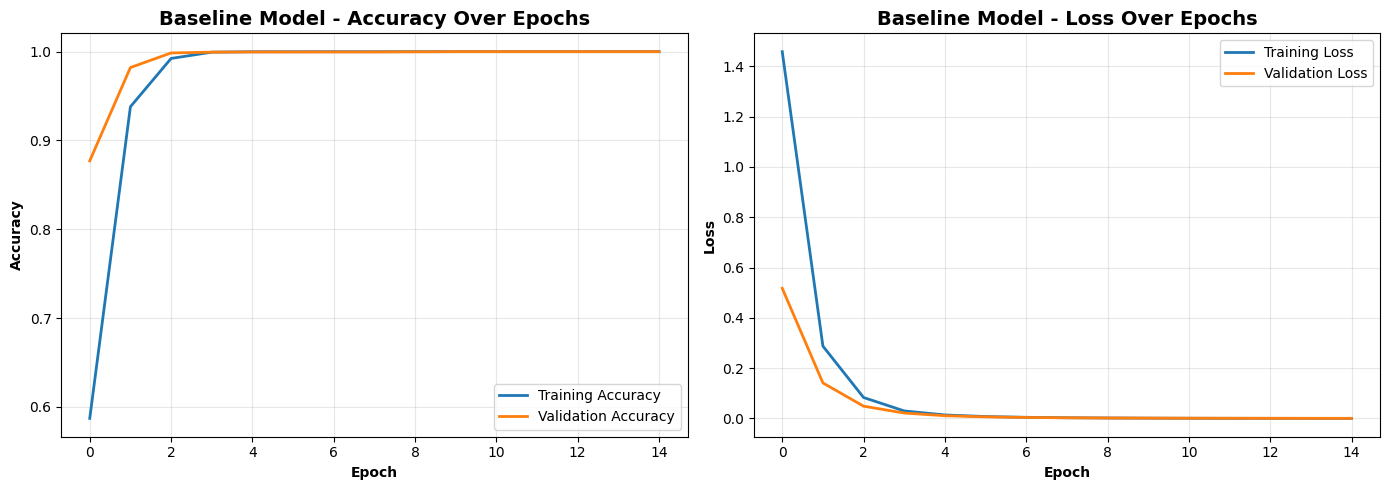

In [8]:
#visualizing the training history 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#plot accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Baseline Model - Accuracy Over Epochs', fontweight='bold', fontsize=14)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

#plot loss
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Baseline Model - Loss Over Epochs', fontweight='bold', fontsize=14)
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('Loss', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/baseline_learning_curves.png', dpi=300, bbox_inches='tight')
print("Learning curves saved to: results/figures/baseline_learning_curves.png")
plt.show()

### results 
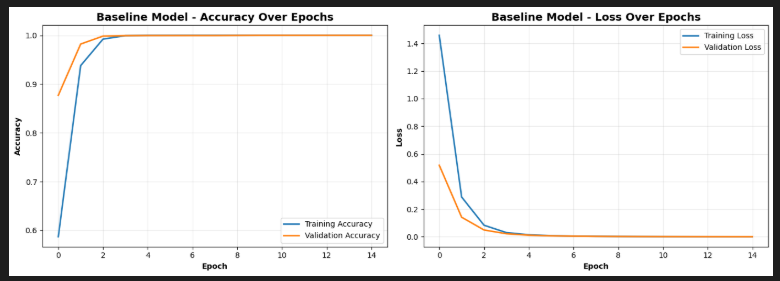

evaluate on validation set 

In [9]:
#evaluate on validation set
val_loss, val_accuracy = baseline_model.evaluate(X_val, y_val, verbose=0)

print(f"\nValidation set perfromance:")
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

#get predictions
y_pred = baseline_model.predict(X_val, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

#calculate metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

print(f"\ndetailed metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Validation set perfromance:
Validation loss: 0.0012
Validation accuracy: 1.0000 (100.00%)

detailed metrics:
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


### results 
Validation set perfromance:
Validation loss: 0.0012
Validation accuracy: 1.0000 (100.00%)

detailed metrics:
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

### eval


confusion matrix 


Confusion matrix saved to: results/figures/baseline_confusion_matrix.png


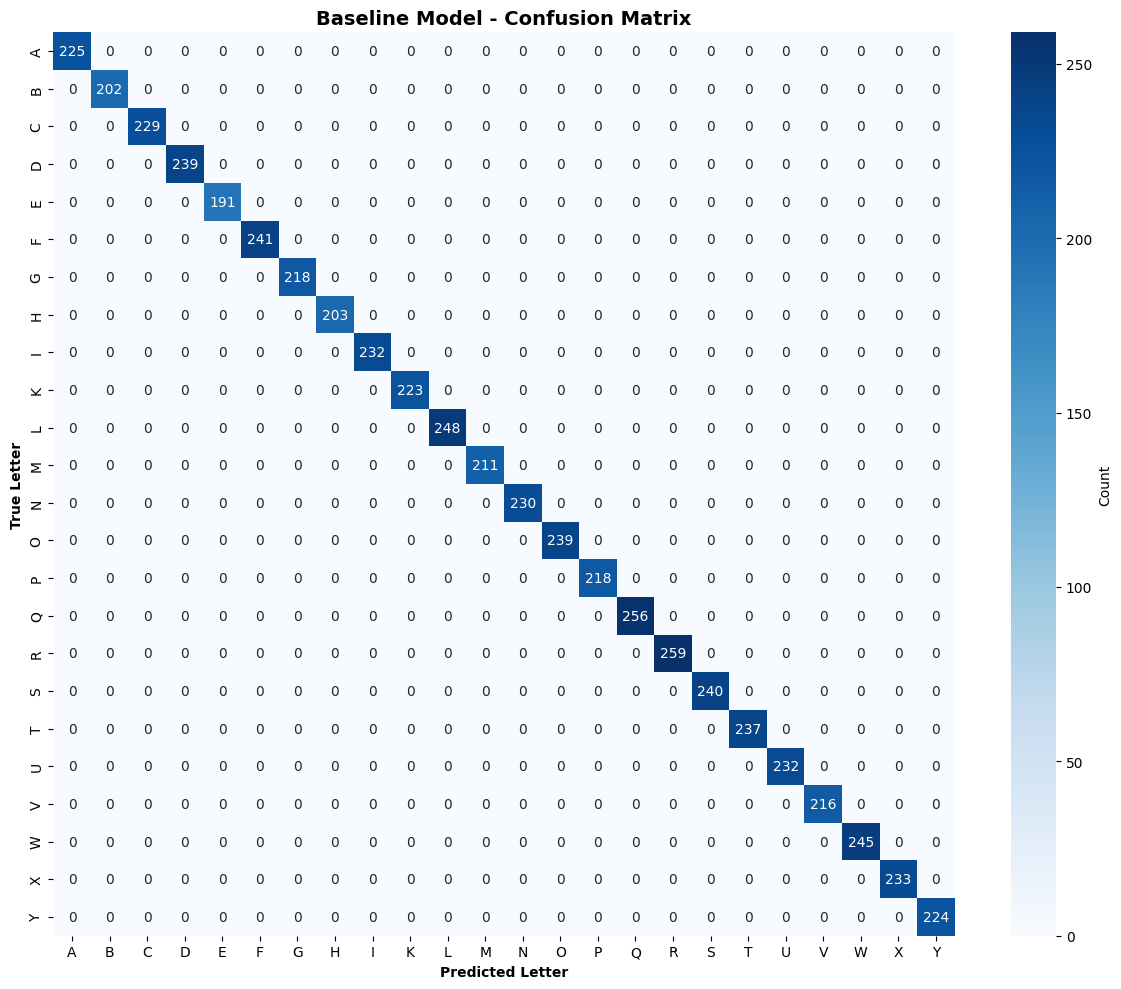


 most commonly confused letters:


In [10]:
#create confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

#plot confusion matrix
plt.figure(figsize=(12, 10))
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 
           'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R',
           'S', 'T', 'U', 'V', 'W', 'X', 'Y']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=letters, yticklabels=letters,
            cbar_kws={'label': 'Count'})
plt.title('Baseline Model - Confusion Matrix', fontweight='bold', fontsize=14)
plt.xlabel('Predicted Letter', fontweight='bold')
plt.ylabel('True Letter', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/baseline_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\nConfusion matrix saved to: results/figures/baseline_confusion_matrix.png")
plt.show()

#find most confused pairs
print("\n most commonly confused letters:")
confused_pairs = []
for i in range(24):
    for j in range(24):
        if i != j and cm[i][j] > 10:  #if more than 10 confusions
            confused_pairs.append((letters[i], letters[j], cm[i][j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)
for true_letter, pred_letter, count in confused_pairs[:5]:
    print(f"   {true_letter} to {pred_letter}: {count} times")

### results 
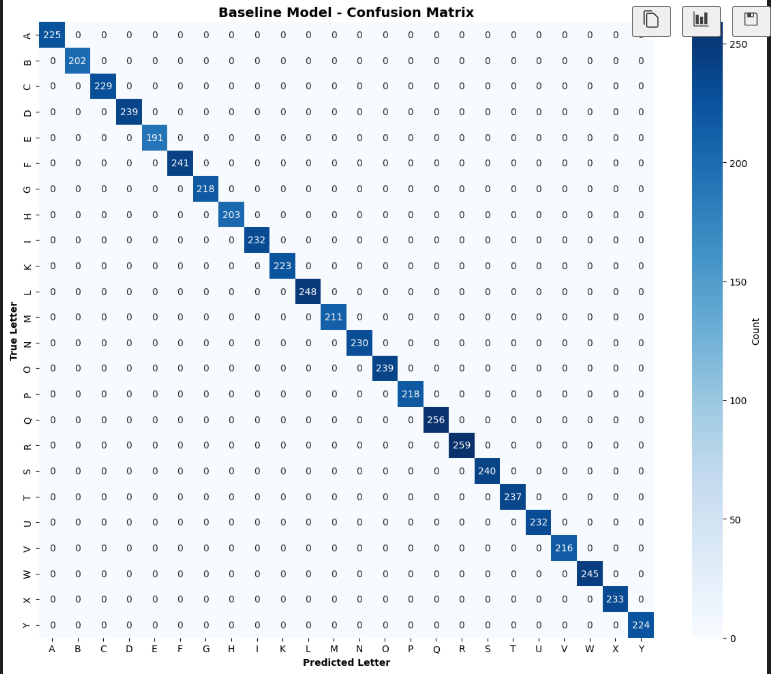

per class accuracy 


Per-class accuracy chart saved to: results/figures/baseline_per_class_accuracy.png


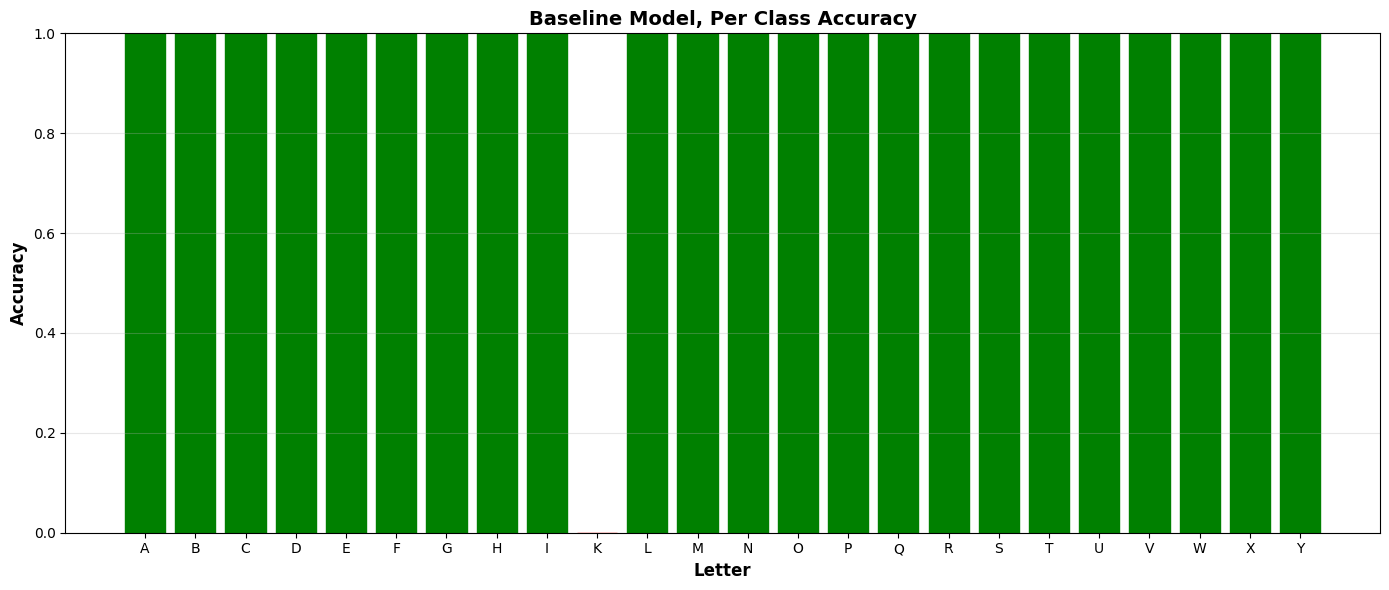


Worst performing letters:
   K: 0.000 (0.0%)
   A: 1.000 (100.0%)
   B: 1.000 (100.0%)
   C: 1.000 (100.0%)
   D: 1.000 (100.0%)


In [11]:
#calculate per class accuracy
per_class_acc = []
for i in range(24):
    class_mask = (y_true_classes == i)
    if class_mask.sum() > 0:
        acc = (y_pred_classes[class_mask] == i).sum() / class_mask.sum()
        per_class_acc.append(acc)
    else:
        per_class_acc.append(0)

#plot per class accuracy
plt.figure(figsize=(14, 6))
bars = plt.bar(range(24), per_class_acc, color='steelblue', edgecolor='black')
plt.xlabel('Letter', fontweight='bold', fontsize=12)
plt.ylabel('Accuracy', fontweight='bold', fontsize=12)
plt.title('Baseline Model, Per Class Accuracy', fontweight='bold', fontsize=14)
plt.xticks(range(24), letters)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

#color bars (key: green if >0.8, yellow if 0.6-0.8, red if <0.6)
for i, bar in enumerate(bars):
    if per_class_acc[i] >= 0.8:
        bar.set_color('green')
    elif per_class_acc[i] >= 0.6:
        bar.set_color('orange')
    else:
        bar.set_color('red')

plt.tight_layout()
plt.savefig('../results/figures/baseline_per_class_accuracy.png', dpi=300, bbox_inches='tight')
print("\nPer-class accuracy chart saved to: results/figures/baseline_per_class_accuracy.png")
plt.show()

#print worst performing letters
worst_letters = sorted(zip(letters, per_class_acc), key=lambda x: x[1])
print("\nWorst performing letters:")
for letter, acc in worst_letters[:5]:
    print(f"   {letter}: {acc:.3f} ({acc*100:.1f}%)")

### results
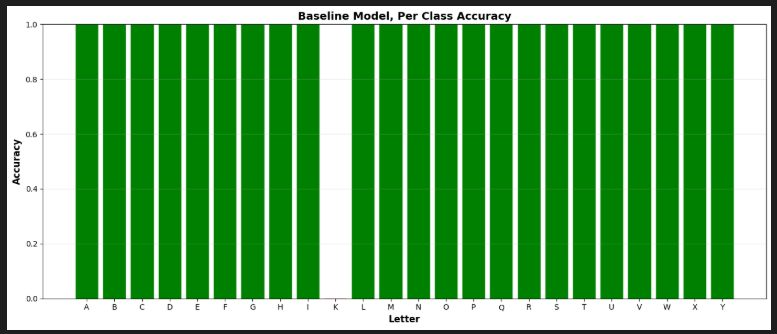


Worst performing letters:
   K: 0.000 (0.0%)
   A: 1.000 (100.0%)
   B: 1.000 (100.0%)
   C: 1.000 (100.0%)
   D: 1.000 (100.0%)

### eval

summary 